In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits
import healpy as hp
import yaml

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/Users/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
nmad = lambda x: 1.4826 * np.median(np.abs(x-np.median(x)))

In [4]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_cumulative_lrg.fits'))
print(len(cat))

cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.33 * cat['TSNR2_LRG']

lrg = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/catalogs/main_lrg_minobs_1_20210913.fits', columns=['TARGETID', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'Z_PHOT_MEDIAN', 'pz_bin']))
lrg1 = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/catalogs/main_lrg_minobs_1_20210913_more.fits', columns=['PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'galdepth_gmag_ebv', 'galdepth_rmag_ebv', 'galdepth_zmag_ebv', 'psfdepth_w1mag_ebv']))
lrg = hstack([lrg, lrg1], join_type='exact')
mask = np.in1d(lrg['TARGETID'], cat['TARGETID'])
lrg = lrg[mask]
cat = join(cat, lrg, keys='TARGETID')
print(len(cat))

# # Add NOBS columns
# main_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0'
# lrg = []
# for field in ['north', 'south']:
#     lrg.append(Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_{}_1.0.0_basic.fits'.format(field)), columns=['TARGETID', 'NOBS_G', 'NOBS_R', 'NOBS_Z'])))
# lrg = vstack(lrg)
# cat = join(cat, lrg, keys='TARGETID')
# print(len(cat))

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Remove QSO targets
# mask = cat['DESI_TARGET'] & 2**2 ==0
# print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# Require a minimum depth
min_depth = 950.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers), 'bad fibers')
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Martin's EBV cut
mask = cat['EBV']<0.15
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's NOBS cut
mask = (cat['NOBS_G']>1) & (cat['NOBS_R']>1) & (cat['NOBS_Z']>1)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=2500
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['TARGET_RA'], cat['TARGET_DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(mask_bad), np.sum(~mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

346063
346063
FIBERSTATUS 340944 5119 0.014792104327824702
No data 340944 0 0.0
LRG mask 306665 34279 0.10054143789009339
Min depth 256649 50016 0.1630965385681444
199 bad fibers
Bad fibers 246939 9710 0.03783377297398392
EBV 245842 1097 0.004442392655676098
NOBS 236936 8906 0.03622651947185591
STARDENS 10666 226270 0.045016375730154976
226270 226253 17
226253 226253 0


In [5]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]

Quality 221781 4472 0.01976548377259086


71978 149803


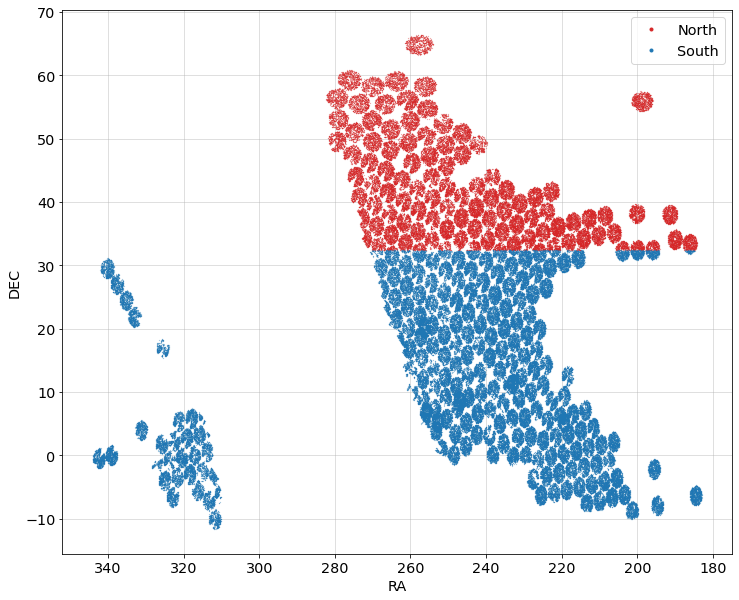

In [6]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

plt.figure(figsize=(12, 10))
plt.plot(cat['TARGET_RA'][mask_north], cat['TARGET_DEC'][mask_north], 'C3.', ms=.3, label='North')
plt.plot(cat['TARGET_RA'][mask_south], cat['TARGET_DEC'][mask_south], 'C0.', ms=.3, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

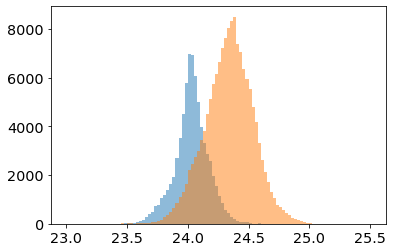

In [8]:
plt.hist(cat['galdepth_gmag_ebv'][mask_north], 100, range=(23, 25.5), alpha=0.5)
plt.hist(cat['galdepth_gmag_ebv'][mask_south], 100, range=(23, 25.5), alpha=0.5)
plt.show()

In [9]:
# mask_north1 = mask_north & (cat['galdepth_gmag_ebv']<np.median(cat['galdepth_gmag_ebv'][mask_north]))
# mask_south1 = mask_south & (cat['galdepth_gmag_ebv']<np.median(cat['galdepth_gmag_ebv'][mask_south]))
# mask_north1 = mask_north & (cat['galdepth_gmag_ebv']<np.percentile(cat['galdepth_gmag_ebv'][mask_north], 25.))
# mask_south1 = mask_south & (cat['galdepth_gmag_ebv']<np.percentile(cat['galdepth_gmag_ebv'][mask_south], 25.))
mask_north1 = mask_north & (cat['galdepth_gmag_ebv']<np.median(cat['galdepth_gmag_ebv'][mask_north]))
mask_north1 &= (cat['galdepth_rmag_ebv']<np.median(cat['galdepth_rmag_ebv'][mask_north]))
mask_north1 &= mask_north & (cat['galdepth_zmag_ebv']<np.median(cat['galdepth_zmag_ebv'][mask_north]))
mask_south1 = mask_south & (cat['galdepth_gmag_ebv']<np.median(cat['galdepth_gmag_ebv'][mask_south]))
mask_south1 &= (cat['galdepth_rmag_ebv']<np.median(cat['galdepth_rmag_ebv'][mask_south]))
mask_south1 &= (cat['galdepth_zmag_ebv']<np.median(cat['galdepth_zmag_ebv'][mask_south]))

mask = mask_north1 | mask_south1
print(np.sum(mask)/len(mask))
cat = cat[mask]
print(len(mask))

mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

0.22767053985688585
221781


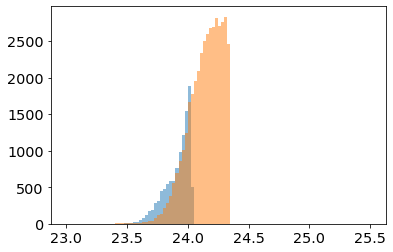

In [10]:
plt.hist(cat['galdepth_gmag_ebv'][mask_north], 100, range=(23, 25.5), alpha=0.5)
plt.hist(cat['galdepth_gmag_ebv'][mask_south], 100, range=(23, 25.5), alpha=0.5)
plt.show()

In [11]:
# numbers from target_densities_and_qso_weight.ipynb
area_north_tot = 4212.9212
area_south_tot = 12443.3916
density_north = 606.51
density_south = 598.46

area_south = np.sum(mask_south)/density_south
print(area_south)

area_north = np.sum(mask_north)/density_north
print(area_north)

area = area_south + area_north
print(area)

66.24669986298164
17.884288799854907
84.13098866283656


--------
# Weights

In [12]:
# numbers from target_densities_and_qso_weight.ipynb
densities = {'all_south': 598.4604711789348,
             'all_north': 606.5131244325197,
             'bin_1_south': 82.7460899004416,
             'bin_1_north': 84.14565171548901,
             'bin_2_south': 148.14232801288676,
             'bin_2_north': 150.72036002002602,
             'bin_3_south': 160.62839330717517,
             'bin_3_north': 164.0460305784974,
             'bin_4_south': 146.88800760718644,
             'bin_4_north': 151.32279236554436}

In [13]:
cat['weight'] = np.ones(len(cat))

In [14]:
# QSO weights

qso_target = cat['DESI_TARGET'] & 2**2>0
# The "0.00611" number is from target_densities_and_qso_weight.ipynb
cat['weight'][qso_target] = 0.00611 / (np.sum(qso_target)/len(qso_target))
print(np.sum(cat['weight'][qso_target])/np.sum(cat['weight']))

0.006162293733786368


In [15]:
# Redshift success (zfiber) weights

def failure_rate_func(x, a, b, c):
    return np.clip(np.exp(a*(x + b)) * c, 0, 1)

zfiber_coeffs = [3.2319795581242428, -18.47796832177645, 2.663839936815595e-06]
zfiber_weight = 1 / (1-failure_rate_func(cat['zfibermag'], *zfiber_coeffs))
cat['weight'] = cat['weight'] * zfiber_weight

In [16]:
# Zero weight for stars

mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['weight'][mask_star] = 0

In [17]:
# Weights for the full sample (i.e. no imaging weights)
cat['weight_full'] = cat['weight'].copy()

mask = mask_north.copy()
renorm_factor = densities['all_north'] / np.sum(cat['weight_full'][mask])
cat['weight_full'][mask] = cat['weight_full'][mask] * renorm_factor
print('north', np.sum(cat['weight_full'][mask]))

mask = mask_south.copy()
renorm_factor = densities['all_south'] / np.sum(cat['weight_full'][mask])
cat['weight_full'][mask] = cat['weight_full'][mask] * renorm_factor
print('South', np.sum(cat['weight_full'][mask]))

north 606.5131244325197
South 598.4604711789348


In [18]:
# Imaging weights

weights_path = '/Users/rongpu/Documents/Data/lrg_xcorr/imaging_weights/v1.1/main_lrg_linear_coeffs_pz.yaml'

# Load weights
with open(weights_path, "r") as f:
    linear_coeffs = yaml.safe_load(f)

cat['check'] = 0  # for sanity check
for field in ['north', 'south']:
    if field=='north':
        mask_field = mask_north.copy()
    elif field=='south':
        mask_field = mask_south.copy()
    else:
        raise ValueError()
    for pz_bin in range(1, 5):
        mask = mask_field & (cat['pz_bin']==pz_bin)
        cat1 = cat[mask].copy()

        xnames_fit = list(linear_coeffs['south_bin_1'].keys())
        xnames_fit.remove('intercept')
        # Assign zero weights to objects with invalid imaging properties
        # (their fraction should be negligibly small)
        mask_bad = np.full(len(cat1), False)
        for col in xnames_fit:
            mask_bad |= ~np.isfinite(cat1[col])
        if np.sum(mask_bad)!=0:
            print('{} invalid objects'.format(np.sum(mask_bad)))

        weights = np.zeros(len(cat1))
        bin_str = '{}_bin_{}'.format(field, pz_bin)

        # create array of coefficients, with the first coefficient being the intercept
        coeffs = np.array([linear_coeffs[bin_str]['intercept']]+[linear_coeffs[bin_str][xname] for xname in xnames_fit])

        data = np.column_stack([cat1[~mask_bad][xname] for xname in xnames_fit])
        # create 2-D array of imaging properties, with the first columns being unity
        data1 = np.insert(data, 0, 1., axis=1)
        # wt = coeff0 + coeff1 * rand['EBV'] + coeff2 * rand['PSFSIZE_G'] + ...
        weights[~mask_bad] = 1/np.dot(coeffs, data1.T)  # 1/predicted_density as weights for objects

        cat['weight'][mask] = cat['weight'][mask] * weights
        cat['check'][mask] = cat['check'][mask] + 1  # sanity check; maximum=1

3 invalid objects
3 invalid objects
1 invalid objects
9 invalid objects
7 invalid objects
3 invalid objects
9 invalid objects


In [19]:
# Renormalize the weights so that the total density (targets per sq. deg.)

for field in ['north', 'south']:
    if field=='north':
        mask_field = mask_north.copy()
    elif field=='south':
        mask_field = mask_south.copy()
    else:
        raise ValueError()
    for pz_bin in range(1, 5):
        mask = mask_field & (cat['pz_bin']==pz_bin)
        renorm_factor = densities['bin_{}_{}'.format(pz_bin, field)] / np.sum(cat['weight'][mask])
        cat['weight'][mask] = cat['weight'][mask] * renorm_factor
        print('{}_{}'.format(field, pz_bin), np.sum(cat['weight'][mask]))

north_1 84.14565171548902
north_2 150.72036002002602
north_3 164.0460305784974
north_4 151.32279236554436
south_1 82.7460899004416
south_2 148.14232801288676
south_3 160.62839330717517
south_4 146.88800760718644


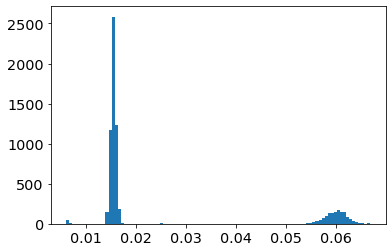

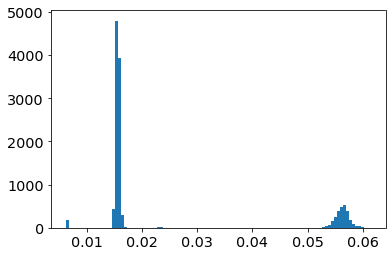

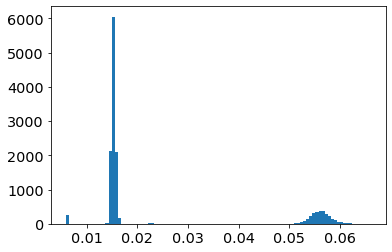

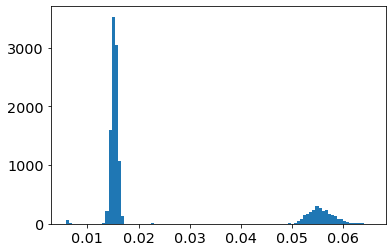

In [20]:
mask = cat['weight']!=0
mask &= cat['pz_bin']!=-1

for pz_bin in range(1, 5):
    mask1 = mask & (cat['pz_bin']==pz_bin)
    plt.hist(cat['weight'][mask1], 100)
    plt.show()

--------

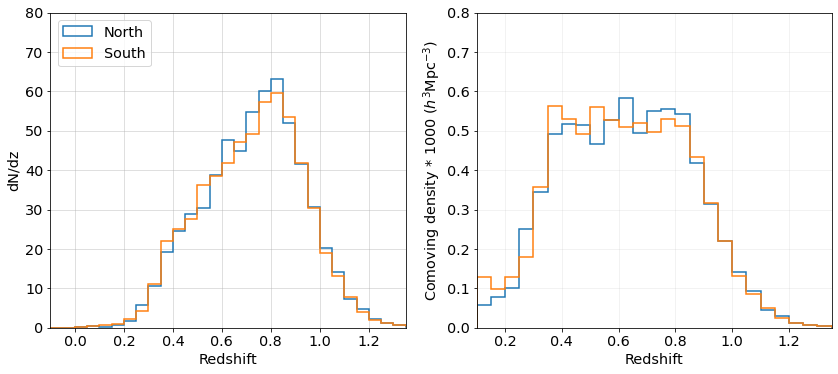

In [21]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=cat['weight_full'][mask_north],
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=cat['weight_full'][mask_south],
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

In [22]:
print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star)/len(mask_star)))

print('South:\n')
mask_all = mask_south & (cat['pz_bin']!=-1)
for pz_bin in range(1, 5):
    mask = mask_south & (cat['pz_bin']==pz_bin)
    print('bin {} fraction: {:.4f}'.format(pz_bin, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
#     print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
#         np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))
    print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star & mask)/np.sum(mask)))
    print()

print()

print('North:\n')
mask_all = mask_north & (cat['pz_bin']!=-1)
for pz_bin in range(1, 5):
    mask = mask_north & (cat['pz_bin']==pz_bin)
    print('bin {} fraction: {:.4f}'.format(pz_bin, np.sum(mask)/np.sum(mask_all)))
    # print(np.percentile(cat['Z'][mask], [2, 16, 50, 84, 98]))
    print('mean redshift: {:.3f}'.format(np.median(cat['Z'][mask])))
#     print('1-sigma width: {:.3f};   2-sigma width: {:.3f}'.format(np.percentile(cat['Z'][mask], 84)-np.percentile(cat['Z'][mask], 16),
#         np.percentile(cat['Z'][mask], 98)-np.percentile(cat['Z'][mask], 2)))
    print('nmad: {:.3f}'.format(nmad(cat['Z'][mask])))
    print('stellar fraction: {:.2f}%'.format(100*np.sum(mask_star & mask)/np.sum(mask)))
    print()

stellar fraction: 0.41%
South:

bin 1 fraction: 0.1522
mean redshift: 0.477
nmad: 0.060
stellar fraction: 0.18%

bin 2 fraction: 0.2714
mean redshift: 0.629
nmad: 0.070
stellar fraction: 0.10%

bin 3 fraction: 0.3019
mean redshift: 0.787
nmad: 0.070
stellar fraction: 0.30%

bin 4 fraction: 0.2745
mean redshift: 0.916
nmad: 0.087
stellar fraction: 0.62%


North:

bin 1 fraction: 0.1435
mean redshift: 0.471
nmad: 0.059
stellar fraction: 0.07%

bin 2 fraction: 0.2761
mean redshift: 0.628
nmad: 0.068
stellar fraction: 0.15%

bin 3 fraction: 0.3009
mean redshift: 0.786
nmad: 0.067
stellar fraction: 0.34%

bin 4 fraction: 0.2794
mean redshift: 0.915
nmad: 0.091
stellar fraction: 0.33%



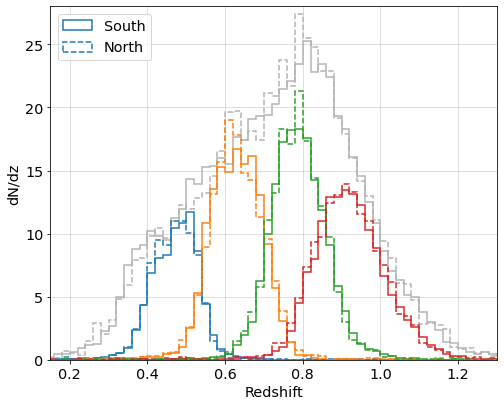

In [23]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=cat['weight_full'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=cat['weight_full'][mask],
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    mask = mask_north & (cat['pz_bin']==pz_bin)
    ax.hist(cat['Z'][mask], weights=cat['weight'][mask],
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 28)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

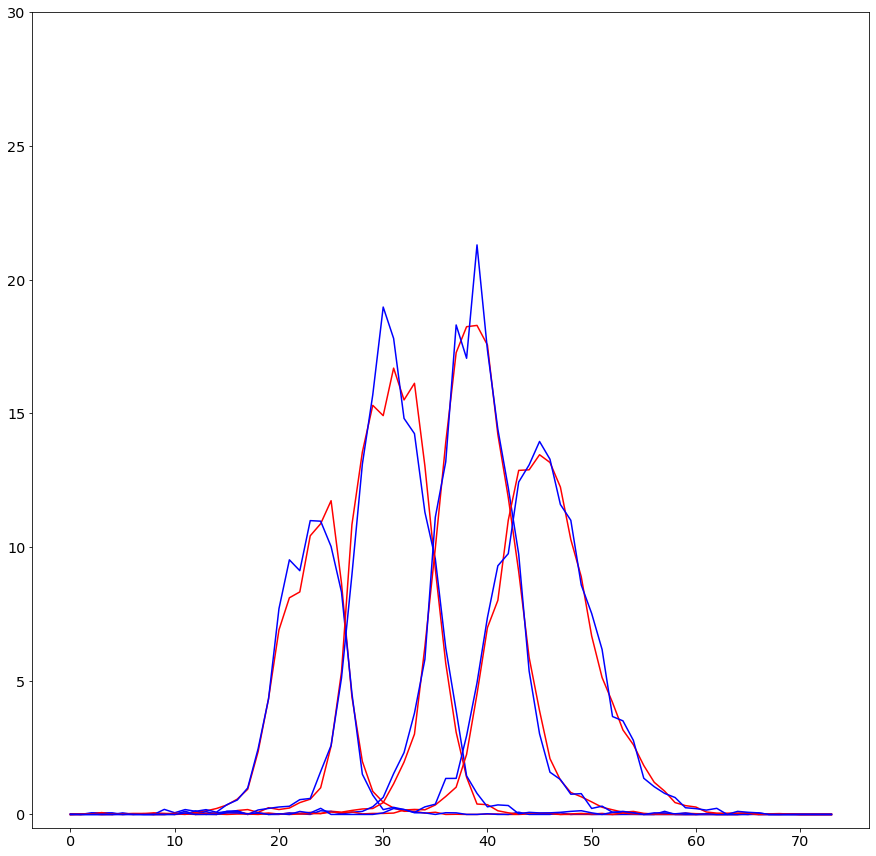

In [27]:
bins = np.round(np.arange(0., 1.5, 0.02), 2)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_north.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight_full'][mask])[0]
        t['all_north'] = surf_density
        t['all_north'].format = '%.2f'
    else:
        mask = mask_north & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_north'.format(pz_bin)] = surf_density
        t['bin_{}_north'.format(pz_bin)].format = '%.2f'

for pz_bin in range(0, 5):
    if pz_bin==0:
        mask = mask_south.copy()
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight_full'][mask])[0]
        t['all_south'] = surf_density
        t['all_south'].format = '%.2f'
    else:
        mask = mask_south & (cat['pz_bin']==pz_bin)
        mask &= (~mask_star)
        surf_density = np.histogram(cat['Z'][mask], bins=bins, weights=cat['weight'][mask])[0]
        t['bin_{}_south'.format(pz_bin)] = surf_density
        t['bin_{}_south'.format(pz_bin)].format = '%.2f'

plt.figure(figsize=(15, 15))
# plt.plot(t['all_south'.format(pz_bin)], color='r')
# plt.plot(t['all_north'.format(pz_bin)], color='b')
for pz_bin in range(1, 5):
    plt.plot(t['bin_{}_south'.format(pz_bin)], color='r')
    plt.plot(t['bin_{}_north'.format(pz_bin)], color='b')
plt.ylim(-0.5, 30)
plt.show()